In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


/var/folders/2m/t5bb62r50jbb_r1gf5dsdy680000gr/T/ipykernel_95566/256808149.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [8]:
# Load the data from data directory from csv using pandas

# Load the full data
full_data = pd.read_csv('../../data/full_allBirds_unilateral_markers.csv')


In [9]:
full_data.head()

,frameID,time,HorzDistance,VertDistance,body_pitch,wingtip_rot_xyz_1,wingtip_rot_xyz_2,wingtip_rot_xyz_3,primary_rot_xyz_1,primary_rot_xyz_2,primary_rot_xyz_3,secondary_rot_xyz_1,secondary_rot_xyz_2,secondary_rot_xyz_3,tailtip_rot_xyz_1,tailtip_rot_xyz_2,tailtip_rot_xyz_3,Left,Obstacle,IMU
0,01_05_002_007638,-0.020,4.470163,0.252610,-4.890324,0.494295,0.138174,-0.083475,0.315180,0.102529,-0.204815,0.367978,-0.056806,-0.009688,0.187713,-0.203856,-0.027699,1,0,0
1,01_05_002_007653,0.055,4.158944,0.241417,8.010411,0.116981,-0.005289,-0.290868,0.135628,0.069017,-0.183151,0.096816,-0.064575,-0.136641,0.132768,-0.226216,-0.100645,0,0,0
2,01_05_002_007654,0.060,4.138285,0.236820,7.635492,0.145859,-0.018671,-0.256069,0.153382,0.059498,-0.151932,0.102852,-0.065182,-0.107341,0.130517,-0.229906,-0.094197,0,0,0
3,01_05_002_007658,0.080,4.056010,0.217725,6.516280,0.267176,-0.061095,-0.054060,0.201597,0.025155,0.017514,0.134325,-0.062892,-0.005201,0.130992,-0.235505,-0.069155,0,0,0
4,01_05_002_007659,0.085,4.035488,0.212977,6.389686,0.281157,-0.066358,0.012597,0.200494,0.024743,0.064762,0.137564,-0.063398,0.021865,0.131680,-0.235297,-0.064582,0,0,0


For testing DMD, need to subset the data usefully and make a numpy matrix with each. 

In [22]:
# Select the data which has frameID that starts with 04_
toothless_only = full_data[full_data['frameID'].str.startswith('04_')].reset_index(drop=True)
toothless_only = toothless_only[toothless_only['IMU']==0].reset_index(drop=True)

# Select the data where frameID contains _09_
toothless_9m = toothless_only[toothless_only['frameID'].str.contains('_09_')].reset_index(drop=True)
toothless_9m_no_obstacle = toothless_9m[toothless_9m['Obstacle']==0].reset_index(drop=True)

toothless_9m_with_obstacle = toothless_9m[toothless_9m['Obstacle']==1].reset_index(drop=True)
toothless_9m_with_obstacle.head()

toothless_5m_no_obstacle = toothless_only[toothless_only['frameID'].str.contains('_05_')].reset_index(drop=True)
toothless_5m_no_obstacle.head()

toothless_12m_no_obstacle = toothless_only[toothless_only['frameID'].str.contains('_12_')].reset_index(drop=True)
toothless_12m_no_obstacle.head()


,frameID,time,HorzDistance,VertDistance,body_pitch,wingtip_rot_xyz_1,wingtip_rot_xyz_2,wingtip_rot_xyz_3,primary_rot_xyz_1,primary_rot_xyz_2,primary_rot_xyz_3,secondary_rot_xyz_1,secondary_rot_xyz_2,secondary_rot_xyz_3,tailtip_rot_xyz_1,tailtip_rot_xyz_2,tailtip_rot_xyz_3,Left,Obstacle,IMU
0,04_12_101_001185,-0.030,11.499332,0.276187,2.393211,0.172039,-0.016297,-0.442432,0.141759,0.070774,-0.312285,0.162779,-0.106871,-0.226782,0.168439,-0.236545,-0.067568,1,0,0
1,04_12_101_001185,-0.030,11.499332,0.276187,2.393211,0.208951,0.003934,-0.429666,0.167571,0.079852,-0.297911,0.169921,-0.095493,-0.211744,0.154861,-0.247628,-0.045616,0,0,0
2,04_12_101_001186,-0.025,11.481457,0.273949,3.144327,0.149676,-0.024094,-0.419549,0.141226,0.069741,-0.291483,0.149946,-0.101847,-0.209808,0.164706,-0.240161,-0.070441,1,0,0
3,04_12_101_001186,-0.025,11.481457,0.273949,3.144327,0.183924,-0.014857,-0.406716,0.164984,0.078240,-0.277708,0.155084,-0.090325,-0.196410,0.153624,-0.248515,-0.048600,0,0,0
4,04_12_101_001187,-0.020,11.463577,0.271129,3.549593,0.136478,-0.030825,-0.391332,0.146508,0.068381,-0.267516,0.142858,-0.096181,-0.188957,0.161908,-0.243009,-0.071972,1,0,0


(13, 20969)


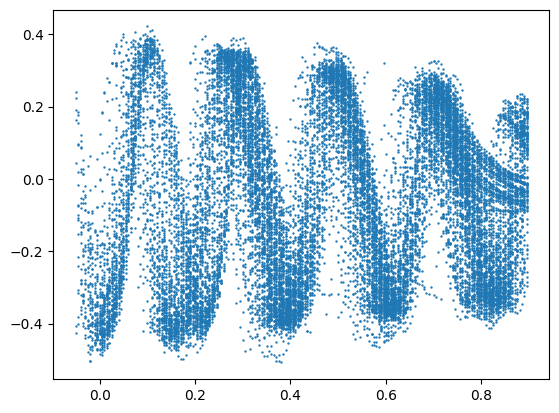

In [35]:
# Now to convert these data to numpy arrays

# Select the columns that we want to keep in the numpy array
columns = ['time','wingtip_rot_xyz_1',	'wingtip_rot_xyz_2',	'wingtip_rot_xyz_3',	'primary_rot_xyz_1',	'primary_rot_xyz_2',	'primary_rot_xyz_3',	'secondary_rot_xyz_1',	'secondary_rot_xyz_2',	'secondary_rot_xyz_3',	'tailtip_rot_xyz_1',	'tailtip_rot_xyz_2',	'tailtip_rot_xyz_3']

# Cut off everyting after 1 second
toothless_9m_no_obstacle = toothless_9m_no_obstacle[toothless_9m_no_obstacle['time'] < 0.9]


# Convert the data to numpy arrays
data = toothless_9m_no_obstacle[columns].to_numpy().T
print(data.shape)

# Save as numpy array
np.save('../../data/toothless_9m_no_obstacle.npy', data)

# Quickly plot this using matplotlib
plt.scatter(data[0,:], data[3,:], s=0.5)

In [36]:
# The first 200 columns
data = data[:,0:200]

# numpy range from 0 to 200
x = np.arange(0,200)

In [ ]:
plt.stem